In [1]:
import base64
import json
import re
import time
from typing import Annotated

from dotenv import load_dotenv
import instructor
from instructor.processing.multimodal import Image
from openai import OpenAI
from pydantic import BaseModel, conlist, StringConstraints
import polars as pl

load_dotenv()

image_root = './captchas/media/upload/1/'
audio_root = './captchas/media/upload/2/'

image_input_type = 'input_image'
audio_input_type = 'input_audio'

In [2]:
def get_b64_file(path: str):
    f = open(path, 'rb')
    return base64.b64encode(f.read()).decode()

In [3]:
image_data_no_file = []

with open('./captchas/testing/image_transformed.json', 'r') as fp:
    image_data_no_file = json.load(fp)

image_data = [
    {
        'value': data['value'],
        'file_b64': get_b64_file(image_root + data['file_name'])
    } for data in image_data_no_file
]

In [4]:
audio_data_no_file = []

with open('./captchas/testing/audio_transformed.json', 'r') as fp:
    audio_data_no_file = json.load(fp)

audio_data = [
    {
        'value': data['value'],
        'file_bytes': open(audio_root + data['file_name'], 'rb')
    } for data in audio_data_no_file
]

In [5]:
class Solution(BaseModel):
    characters: conlist(Annotated[str, StringConstraints(min_length=1, max_length=1)], min_length=5, max_length=5)

client = instructor.from_openai(OpenAI())

Test image-based CAPTCHA solving

In [6]:
# Only test a small sample on each model to lower costs
image_test_sets = [
    {
        'model': 'gpt-4.1',
        'data': image_data
    },
    {
        'model': 'gpt-4.1-mini',
        'data': image_data
    },
    {
        'model': 'gpt-4.1-nano',
        'data': image_data
    },
    {
        'model': 'gpt-4o-mini',
        'data': image_data
    },
    # gpt-5 models took too many tokens to complete
    # {
    #     'model': 'gpt-5-mini',
    #     'data': image_data[:20]
    # },
    # {
    #     'model': 'gpt-5-nano',
    #     'data': image_data[:20]
    # }
]

In [7]:
image_outputs = {
    'model': [],
    'truth': [],
    'output': [],
    'time': [],
    'success': [],
    'prompt_tokens': [],
    'completion_tokens': [],
}

for image_test_set in image_test_sets:
    print("Testing", image_test_set['model'])
    model_start = time.time()
    for image_test in image_test_set['data']:
        image_outputs['model'].append(image_test_set['model'])
        image_outputs['truth'].append(image_test['value'])

        try:
            start = time.time()
            output = None

            output, completion = client.chat.completions.create_with_completion(
                model=image_test_set['model'],
                response_model=Solution,
                temperature=0.0,
                max_tokens = 20,
                messages=[
                    {"role": "system", "content": "Transcribe the characters in the image"},
                    {"role": "user", "content": [
                        Image.from_base64(f"data:image/png;base64,{image_test['file_b64']}")
                    ]}
                ]
            )

            image_outputs['output'].append(output.characters)
            image_outputs['time'].append(time.time() - start)
            image_outputs['success'].append(True)
            image_outputs['prompt_tokens'].append(completion.usage.prompt_tokens)
            image_outputs['completion_tokens'].append(completion.usage.completion_tokens)
        except Exception as e:
            print(e)
            image_outputs['output'].append(None)
            image_outputs['time'].append(None)
            image_outputs['success'].append(False)
            image_outputs['prompt_tokens'].append(None)
            image_outputs['completion_tokens'].append(None)
            continue
    model_duration = time.time() - model_start
    print("Time per CAPTCHA", '{:10.4f}'.format(model_duration / len(image_test_set['data'])) + 's')

Testing gpt-4.1
Time per CAPTCHA     1.2508s
Testing gpt-4.1-mini
Time per CAPTCHA     0.7275s
Testing gpt-4.1-nano
Time per CAPTCHA     0.6157s
Testing gpt-4o-mini
Time per CAPTCHA     1.4171s


In [8]:
image_test_results = pl.DataFrame(image_outputs)

Test audio-based CAPTCHA solving

In [9]:
audio_test_sets = [
    {
        'model': 'gpt-4o-transcribe',
        'data': audio_data
    },
    {
        'model': 'gpt-4o-mini-transcribe',
        'data': audio_data
    },
    {
        'model': 'whisper-1',
        'data': audio_data
    }
]

In [10]:
audio_outputs = {
    'model': [],
    'truth': [],
    'output': [],
    'time': [],
    'success': [],
    'prompt_tokens': [],
    'completion_tokens': [],
    'usage_duration': []
}

for audio_test_set in audio_test_sets:
    print("Testing", audio_test_set['model'])
    model_start = time.time()
    for audio_test in audio_test_set['data']:
        audio_outputs['model'].append(audio_test_set['model'])
        audio_outputs['truth'].append(audio_test['value'])

        try:
            start = time.time()
            output = client.audio.transcriptions.create(
                model=audio_test_set['model'],
                file=audio_test['file_bytes'],
                response_format='json'
            )

            audio_outputs['output'].append(output.text)
            audio_outputs['time'].append(time.time() - start)
            audio_outputs['success'].append(True)
            if audio_test_set['model'] == 'whisper-1':
                audio_outputs['prompt_tokens'].append(None)
                audio_outputs['completion_tokens'].append(None)
                audio_outputs['usage_duration'].append(output.usage.seconds)
            else:
                audio_outputs['prompt_tokens'].append(output.usage.input_tokens)
                audio_outputs['completion_tokens'].append(output.usage.output_tokens)
                audio_outputs['usage_duration'].append(None)
        except Exception as e:
            print(e)
            audio_outputs['output'].append(None)
            audio_outputs['time'].append(None)
            audio_outputs['success'].append(False)
            audio_outputs['prompt_tokens'].append(None)
            audio_outputs['completion_tokens'].append(None)
            audio_outputs['usage_duration'].append(None)
            continue
    model_duration = time.time() - model_start
    print("Time per CAPTCHA", '{:10.4f}'.format(model_duration / len(audio_test_set['data'])) + 's')

Testing gpt-4o-transcribe
Time per CAPTCHA     1.1408s
Testing gpt-4o-mini-transcribe
Time per CAPTCHA     0.8854s
Testing whisper-1
Time per CAPTCHA     1.4640s


In [11]:
audio_test_results = pl.DataFrame(audio_outputs)

Visualize and compare data

In [12]:
import matplotlib.pyplot as plt

In [13]:
whisper_price_per_minute = 0.006

model_price_per_token = {
    'gpt-4.1':	{
        'input': 2.00 / 1_000_000,
        'output': 8.00 / 1_000_000
    },
    'gpt-4.1-mini':	{
        'input': 0.40 / 1_000_000,
        'output': 1.60 / 1_000_000
    },
    'gpt-4.1-nano':	{
        'input': 0.10 / 1_000_000,
        'output': 0.40 / 1_000_000
    },
    'gpt-4o-mini': {
        'input': 0.15 / 1_000_000,
        'output': 0.60 / 1_000_000
    },
    'gpt-5-mini': {
        'input': 0.25 / 1_000_000,
        'output': 2.00 / 1_000_000
    },
    'gpt-5-nano': {
        'input': 0.05 / 1_000_000,
        'output': 0.40 / 1_000_000
    },
    # These prices assume we're only passing audio tokens as input to the model (we are)
    'gpt-4o-mini-transcribe': {
        'input': 3.00 / 1_000_000,
        'output': 5.00 / 1_000_000
    },
    'gpt-4o-transcribe': {
        'input': 6.00 / 1_000_000,
        'output': 10.00 / 1_000_000
    },
}

In [14]:
def map_audio_test_results(row):
    model = row[0]
    truth = row[1]
    output = row[2].split(' ')
    time = row[3]
    success = row[4]
    prompt_tokens = row[5]
    completion_tokens = row[6]
    usage_duration = row[7]

    if model == 'whisper-1':
        price = whisper_price_per_minute * usage_duration / 60.0
    else:
        price = model_price_per_token[model]['input'] * prompt_tokens + model_price_per_token[model]['output'] * completion_tokens

    return (model, truth, output, time, success, price, 'audio')

In [15]:
audio_test_results_mapped = audio_test_results.map_rows(map_audio_test_results).rename({
    'column_0': 'model',
    'column_1': 'truth',
    'column_2': 'output',
    'column_3': 'time',
    'column_4': 'success',
    'column_5': 'price',
    'column_6': 'input_type',
})

In [16]:
def map_image_test_results(row):
    model = row[0]
    truth = row[1]
    output = row[2]
    time = row[3]
    success = row[4]
    prompt_tokens = row[5]
    completion_tokens = row[6]

    price = model_price_per_token[model]['input'] * prompt_tokens + model_price_per_token[model]['output'] * completion_tokens

    return (model, truth, output, time, success, price, 'image')

In [17]:
image_test_results_mapped = image_test_results.map_rows(map_image_test_results).rename({
    'column_0': 'model',
    'column_1': 'truth',
    'column_2': 'output',
    'column_3': 'time',
    'column_4': 'success',
    'column_5': 'price',
    'column_6': 'input_type',
})

In [18]:
test_results = pl.concat([image_test_results_mapped, audio_test_results_mapped]).with_columns(
    (pl.col('model') + ' (' + pl.col('input_type') + ')').alias('model_and_modality')
)

shape: (7, 2)
┌────────────────────────────────┬──────────┐
│ model_and_modality             ┆ time     │
│ ---                            ┆ ---      │
│ str                            ┆ f64      │
╞════════════════════════════════╪══════════╡
│ gpt-4o-mini (image)            ┆ 1.417121 │
│ whisper-1 (audio)              ┆ 1.463977 │
│ gpt-4o-mini-transcribe (audio) ┆ 0.885362 │
│ gpt-4.1 (image)                ┆ 1.250763 │
│ gpt-4o-transcribe (audio)      ┆ 1.140833 │
│ gpt-4.1-mini (image)           ┆ 0.727499 │
│ gpt-4.1-nano (image)           ┆ 0.615691 │
└────────────────────────────────┴──────────┘


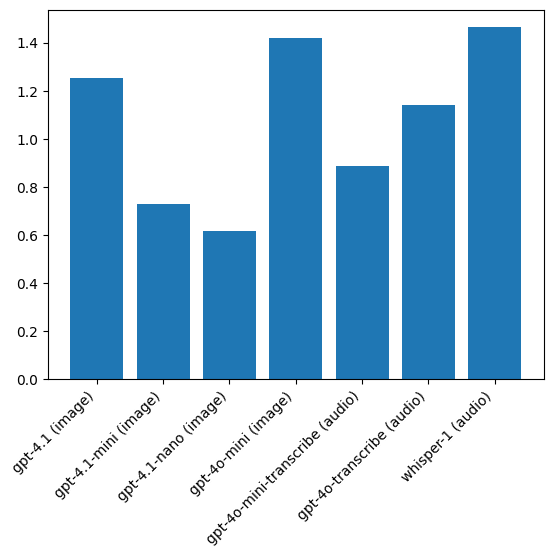

In [19]:
fig, ax = plt.subplots()

models = test_results.unique(subset='model_and_modality')['model_and_modality']
average_time = test_results.group_by('model_and_modality').agg(pl.mean('time'))
print(average_time)

ax.bar(models.sort(), average_time.sort('model_and_modality')['time'])
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

shape: (7, 2)
┌────────────────────────────────┬───────────┐
│ model_and_modality             ┆ price     │
│ ---                            ┆ ---       │
│ str                            ┆ f64       │
╞════════════════════════════════╪═══════════╡
│ gpt-4o-mini-transcribe (audio) ┆ 0.37096   │
│ whisper-1 (audio)              ┆ 1.099     │
│ gpt-4.1-mini (image)           ┆ 0.081184  │
│ gpt-4o-transcribe (audio)      ┆ 0.71622   │
│ gpt-4.1-nano (image)           ┆ 0.03574   │
│ gpt-4.1 (image)                ┆ 0.82      │
│ gpt-4o-mini (image)            ┆ 1.3404525 │
└────────────────────────────────┴───────────┘


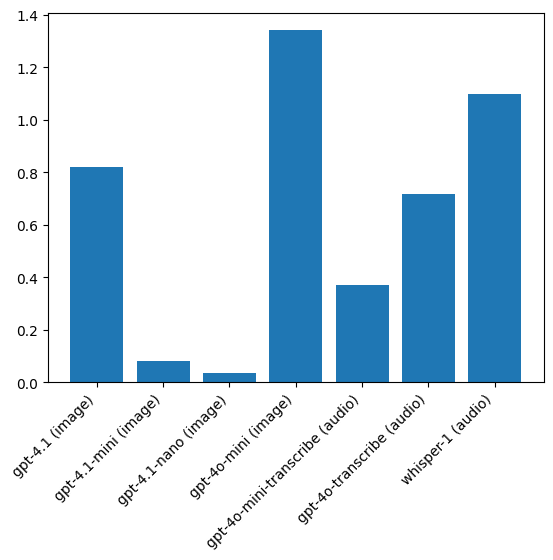

In [55]:
fig, ax = plt.subplots()

average_price = test_results.group_by('model_and_modality').agg(pl.mean('price') * 1000)
print(average_price)

ax.bar(models.sort(), average_price.sort('model_and_modality')['price'])
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

shape: (7, 2)
┌────────────────────────────────┬──────────┐
│ model_and_modality             ┆ time     │
│ ---                            ┆ ---      │
│ str                            ┆ f64      │
╞════════════════════════════════╪══════════╡
│ gpt-4o-mini (image)            ┆ 1.417121 │
│ whisper-1 (audio)              ┆ 1.463977 │
│ gpt-4o-mini-transcribe (audio) ┆ 0.885362 │
│ gpt-4.1 (image)                ┆ 1.250763 │
│ gpt-4o-transcribe (audio)      ┆ 1.140833 │
│ gpt-4.1-mini (image)           ┆ 0.727499 │
│ gpt-4.1-nano (image)           ┆ 0.615691 │
└────────────────────────────────┴──────────┘


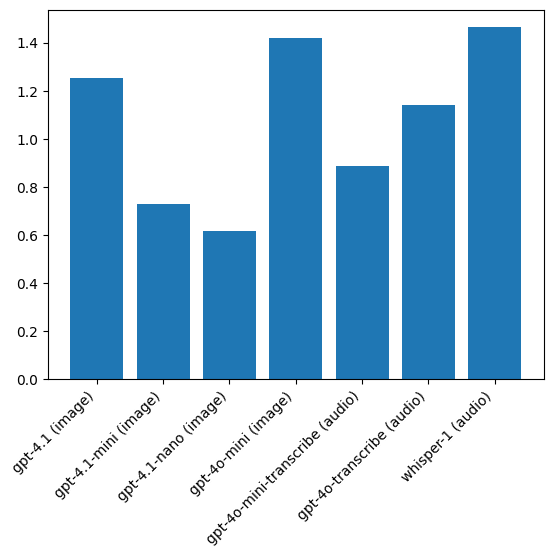

In [21]:
fig, ax = plt.subplots()

viable_average_time = average_time.filter(pl.col('model_and_modality').is_in([
    'gpt-4.1 (image)',
    'gpt-4.1-mini (image)',
    'gpt-4.1-nano (image)',
    'gpt-4o-mini (image)',
    'gpt-4o-mini-transcribe (audio)',
    'gpt-4o-transcribe (audio)',
    'whisper-1 (audio)'
]))
viable_models = viable_average_time.unique(subset='model_and_modality')['model_and_modality']
print(average_time)

ax.bar(viable_models.sort(), viable_average_time.sort('model_and_modality')['time'])
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

Map the audio test results so that they're single, lowercase characters and map the image test results so they're lowercase.

In [22]:
phonetic_map = {
    "alpha": "a",
    "bravo": "b",
    "charlie": "c",
    "delta": "d",
    "echo": "e",
    "foxtrot": "f",
    "golf": "g",
    "hotel": "h",
    "india": "i",
    "juliet": "j",
    "juliett": "j",
    "kelo": "k",
    "keelow": "k",
    "kilo": "k",
    "lima": "l",
    "mike": "m",
    "november": "n",
    "oscar": "o",
    "papa": "p",
    "quebec": "q",
    "romeo": "r",
    "sierra": "s",
    "tango": "t",
    "uniform": "u",
    "victor": "v",
    "whiskey": "w",
    "whisky": "w",
    "xray": "x",
    "yankee": "y",
    "zulu": "z",
    "zero": "0",
    "one": "1",
    "two": "2",
    "three": "3",
    "four": "4",
    "five": "5",
    "six": "6",
    "seven": "7",
    "eight": "8",
    "nine": "9",
    "0": "0",
    "1": "1",
    "2": "2",
    "3": "3",
    "4": "4",
    "5": "5",
    "6": "6",
    "7": "7",
    "8": "8",
    "9": "9",
}

In [37]:
print(test_results.columns)

['model', 'truth', 'output', 'time', 'success', 'price', 'input_type', 'model_and_modality']


In [47]:
def remap_audio_output(messy: list[str]) -> list[str]:
    keys = [re.sub(r'[^\w]', '', s.lower()) for s in messy]
    out = [phonetic_map[key] if key in phonetic_map else key[0] if len(key) > 0 else '' for key in keys]
    while len(out) < 5:
        out.append('')
    return out

In [48]:
def remap_image_output(messy: list[str]) -> list[str]:
    out = [s.lower() for s in messy]
    while len(out) < 5:
        out.append('')
    return out

In [49]:
def remap_output(messy):
    model = messy[0]
    truth = messy[1]
    model_output = [c if c is not None else '' for c in messy[2]]
    completion_time = messy[3]
    success = messy[4]
    price = messy[5]
    input_type = messy[6]
    model_and_modality = messy[7]

    if model_output is not None:
        if messy[5] == 'image':
            clean_output = remap_image_output(model_output)
        else:
            clean_output = remap_audio_output(model_output)
    else:
        clean_output = ['', '', '', '', '']

    out = (
        model,
        completion_time,
        success,
        price,
        input_type,
        model_and_modality,
        truth[0], truth[1], truth[2], truth[3], truth[4],
        clean_output[0], clean_output[1], clean_output[2], clean_output[3], clean_output[4],
    )

    return out

In [50]:
test_results_mapped = test_results.map_rows(remap_output).rename({
    'column_0': 'model',
    'column_1': 'time',
    'column_2': 'success',
    'column_3': 'price',
    'column_4': 'input_type',
    'column_5': 'model_and_modality',
    'column_6': 'truth_0',
    'column_7': 'truth_1',
    'column_8': 'truth_2',
    'column_9': 'truth_3',
    'column_10': 'truth_4',
    'column_11': 'output_0',
    'column_12': 'output_1',
    'column_13': 'output_2',
    'column_14': 'output_3',
    'column_15': 'output_4',
}).with_columns(
    match_0=pl.col('truth_0') == pl.col('output_0'),
    match_1=pl.col('truth_1') == pl.col('output_1'),
    match_2=pl.col('truth_2') == pl.col('output_2'),
    match_3=pl.col('truth_3') == pl.col('output_3'),
    match_4=pl.col('truth_4') == pl.col('output_4'),
).with_columns(
    match=pl.col('match_0') | pl.col('match_1') | pl.col('match_2') | pl.col('match_3') | pl.col('match_4'),
)

shape: (7, 2)
┌────────────────────────────────┬───────┐
│ model_and_modality             ┆ match │
│ ---                            ┆ ---   │
│ str                            ┆ f64   │
╞════════════════════════════════╪═══════╡
│ gpt-4.1-nano (image)           ┆ 0.94  │
│ gpt-4o-transcribe (audio)      ┆ 1.0   │
│ gpt-4o-mini-transcribe (audio) ┆ 1.0   │
│ whisper-1 (audio)              ┆ 1.0   │
│ gpt-4.1 (image)                ┆ 1.0   │
│ gpt-4.1-mini (image)           ┆ 0.99  │
│ gpt-4o-mini (image)            ┆ 1.0   │
└────────────────────────────────┴───────┘


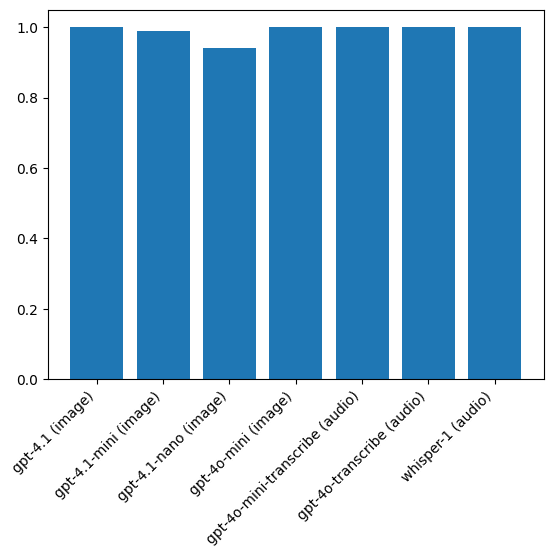

In [54]:
fig, ax = plt.subplots()

models = test_results_mapped.unique(subset='model_and_modality')['model_and_modality']
accuracy = test_results_mapped.group_by('model_and_modality').agg(pl.mean('match'))
print(accuracy)

ax.bar(models.sort(), accuracy.sort('model_and_modality')['match'])
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

Pricing calculations

| Model                  | \$/M input | \$/M output | \$/M audio input |
|------------------------|------------|-------------|------------------|
| gpt-4.1                | \$2.00     | \$8.00      | n/a              |
| gpt-4.1-mini           | \$0.40     | \$1.60      | n/a              |
| gpt-4.1-nano           | \$0.10     | \$0.40      | n/a              |
| gpt-4o-mini            | \$0.15     | \$0.60      | n/a              |
| gpt-4o-mini-transcribe | \$1.25     | \$5.00      | \$3.00           |
| gpt-4o-transcribe      | \$2.50     | \$10.00     | \$6.00           |
| whisper-1              | n/a        | n/a         | \$0.006/m        |
